# T₂-Fitting aus Hahn-Spin-Echo – Einfluss des chemischen Austauschs

Dieses Notebook simuliert eine dichte TE-Reihe (15 Punkte, 25–375 ms) und fittet T₂ für **zwei Varianten**:

| Variante | Config | k [Hz] | Erwartetes T₂ |
|---|---|---|---|
| Ohne Exchange | `config_t2fit_noex.yaml` | 0 | 71.0 ms |
| Mit Exchange | `config_t2fit_cest.yaml` | 2 000 | ≈ 65.6 ms |

Der Unterschied ergibt sich aus dem Rex-Term (schnell-austauschender Pool, z.B. Hydroxyl/Amin):
$$R_{2,\text{eff}} = R_{2,\text{water}} + k \cdot f \cdot \frac{\Delta\omega^2}{\Delta\omega^2 + (2\pi k)^2} = 14.09 + 1.16 \approx 15.25 \text{ Hz} \quad \Rightarrow \quad T_{2,\text{eff}} \approx 65.6 \text{ ms}$$

In [22]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.optimize import curve_fit

from bmc.simulate import simulate
from bmc.utils.seq.write import write_seq
from bmc.utils.results import save_simulation, load_simulation

## Einstellungen

In [23]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve().parent
seq_tmp_dir = wdir / 'seq_lib' / 't2_fitting'
seq_tmp_dir.mkdir(parents=True, exist_ok=True)

series_label = datetime.now().strftime('%Y%m%d_%H%M%S')

configs = {
    'Ohne Austausch': wdir / 'sim_lib' / 'config_t2fit_noex.yaml',
    'Mit Austausch':  wdir / 'sim_lib' / 'config_t2fit_cest.yaml',
}

# ── TE-Reihe ───────────────────────────────────────────────────────────────
TE_values_ms = np.arange(25, 376, 25)   # 25, 50, 75, ..., 375 ms  (15 Punkte)

# ── Sequenz-Parameter ──────────────────────────────────────────────────────
sys = pp.Opts(
    max_grad=500, grad_unit='mT/m',
    max_slew=1e9, slew_unit='T/m/s',
    rf_ringdown_time=0, rf_dead_time=0,
    rf_raster_time=1e-6, gamma=42576400, grad_raster_time=1e-6,
)

B0       = 17
t_pulse  = 2e-3      # [s]
adc_time = 50e-3     # [s]  — kurzes Fenster, nur Echo-Peak benötigt

GAMMA_HZ = sys.gamma * 1e-6
freq_hz  = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 100
z_pos = torch.sort(torch.cat((
    torch.tensor(np.linspace(low, high, n_iso)),
    torch.tensor([0.0])
))).values

print(f"TE-Werte ({len(TE_values_ms)} Punkte): {TE_values_ms} ms")
print(f"Varianten: {list(configs.keys())}")

TE-Werte (15 Punkte): [ 25  50  75 100 125 150 175 200 225 250 275 300 325 350 375] ms
Varianten: ['Ohne Austausch', 'Mit Austausch']


## Sequenzen erstellen und simulieren

Die Sequenz ist für beide Varianten identisch (90° → TE/2 → 180° → TE/2 → ADC).
Nur die Config-Datei (k = 0 vs. k = 150 Hz) unterscheidet sich.

In [24]:
# ── Schritt 1: Sequenzdateien einmal erzeugen ──────────────────────────────
seq_files  = {}
echo_times = {}   # te_ms -> absolute echo time [ms]

for te_ms in TE_values_ms:
    te_s    = float(te_ms) * 1e-3
    te_half = te_s / 2.0

    defs = {
        'TE': te_s, 'b0': B0, 'm0_offset': 0, 'n_ETM': 1,
        'seq_id_string': f't2fit_te_{int(te_ms):04d}ms',
    }
    defs['offsets_ppm'] = np.array([0])
    defs['num_meas']    = 1
    defs['freq']        = freq_hz

    seq = pp.Sequence()

    rf90 = pp.make_gauss_pulse(
        flip_angle=np.pi / 2, system=sys, duration=t_pulse,
        center_pos=0.5, freq_offset=0.0, phase_offset=0.0, return_gz=False,
    )
    rf90.freq_offset = 0.0
    seq.add_block(rf90)
    seq.add_block(pp.make_delay(te_half))

    rf180 = pp.make_gauss_pulse(
        flip_angle=np.pi, system=sys, duration=t_pulse,
        center_pos=0.5, freq_offset=0.0, phase_offset=np.pi / 2, return_gz=False,
    )
    rf180.freq_offset = 0.0
    seq.add_block(rf180)
    seq.add_block(pp.make_delay(te_half))
    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))

    sf = seq_tmp_dir / f"t2fit_te_{int(te_ms):04d}ms.seq"
    write_seq(seq=seq, seq_defs=defs, filename=sf,
              author='DANIEL MIKSCH', use_matlab_names=True)
    seq_files[float(te_ms)]  = sf
    echo_times[float(te_ms)] = (2.5 * t_pulse + te_s) * 1e3   # [ms]

print(f"✓ {len(seq_files)} Sequenzdateien erstellt")

✓ 15 Sequenzdateien erstellt


In [25]:
# ── Schritt 2: Simulation beider Varianten ─────────────────────────────────
result_dirs = {name: {} for name in configs}

for var_name, config_path in configs.items():
    var_slug = 't2fit_noex' if 'noex' in config_path.stem else 't2fit_cest'
    series_dir = wdir / 'results' / 'simulations' / f"{var_slug}_{series_label}"
    series_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*55}")
    print(f"Variante: {var_name}  [{config_path.name}]")
    print(f"{'='*55}")

    for te_ms in TE_values_ms:
        sim = simulate(
            config_file=config_path,
            seq_file=seq_files[float(te_ms)],
            z_positions=z_pos,
            adc_time=adc_time,
            iso_select=None,
            return_zmag=False,
            show_plot=False,
            webhook=False,
            plt_range=[0, 4],
            n_backlog='ALL',
        )
        out = save_simulation(
            sim, label=f"te_{int(te_ms):04d}ms", results_root=series_dir
        )
        result_dirs[var_name][float(te_ms)] = out

    print(f"   → gespeichert in: {series_dir.name}")

print(f"\n✓ Simulation abgeschlossen")


Variante: Ohne Austausch  [config_t2fit_noex.yaml]


BMCTool simulation: 100%|██████████| 5/5 [00:00<00:00,  6.32it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/t2fit_noex_20260517_231629/te_0025ms_20260517_231630


BMCTool simulation: 100%|██████████| 5/5 [00:00<00:00,  6.75it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/t2fit_noex_20260517_231629/te_0050ms_20260517_231630


...

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/t2fit_cest_20260517_231629/te_0325ms_20260517_231651


BMCTool simulation: 100%|██████████| 5/5 [00:00<00:00,  6.97it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/t2fit_cest_20260517_231629/te_0350ms_20260517_231652


BMCTool simulation: 100%|██████████| 5/5 [00:00<00:00,  6.89it/s]

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/t2fit_cest_20260517_231629/te_0375ms_20260517_231652
   → gespeichert in: t2fit_cest_20260517_231629

✓ Simulation abgeschlossen


## Echo-Amplituden extrahieren und T₂ fitten

In [26]:
# ── Extraktion der Echo-Amplituden ─────────────────────────────────────────
n_total_pools = 2
mz_loc        = 4

echo_amps = {name: {} for name in configs}

for var_name in configs:
    for te_ms in sorted(result_dirs[var_name].keys()):
        loaded       = load_simulation(result_dirs[var_name][te_ms])
        m_out        = loaded['m_out']
        t            = loaded['t']
        n_iso_loaded = m_out.shape[0]

        m_x = np.sum(m_out[:, 0,            :], axis=0) / n_iso_loaded
        m_y = np.sum(m_out[:, n_total_pools, :], axis=0) / n_iso_loaded
        mxy = np.abs(m_x + 1j * m_y)
        t_ms = t * 1e3

        t_echo_ms = echo_times[te_ms]
        idx_echo  = int(np.argmin(np.abs(t_ms - t_echo_ms)))
        echo_amps[var_name][te_ms] = float(mxy[idx_echo])

# ── T2-Fit ─────────────────────────────────────────────────────────────────
def t2_model(te_ms, m0, t2_ms):
    return m0 * np.exp(-te_ms / t2_ms)

fit_results = {}
expected = {'Ohne Austausch': 71.0, 'Mit Austausch': 65.6}

print(f"{'Variante':<25} {'T2 (Fit)':<18} {'T2 (erwartet)'}")
print("-" * 60)
for var_name in configs:
    te_arr  = np.array(sorted(echo_amps[var_name].keys()))
    amp_arr = np.array([echo_amps[var_name][te] for te in te_arr])

    popt, pcov = curve_fit(t2_model, te_arr, amp_arr, p0=[1.0, 71.0])
    m0_fit, t2_fit = popt
    t2_err = float(np.sqrt(np.diag(pcov))[1])

    fit_results[var_name] = {
        'te_arr':  te_arr,  'amp_arr': amp_arr,
        't2_fit':  t2_fit,  't2_err':  t2_err,
        'm0_fit':  m0_fit,  'popt':    popt,
    }
    print(f"{var_name:<25} {t2_fit:.2f} ± {t2_err:.2f} ms      {expected[var_name]:.1f} ms")

Variante                  T2 (Fit)           T2 (erwartet)
------------------------------------------------------------
Ohne Austausch            71.00 ± 0.00 ms      71.0 ms
Mit Austausch             65.03 ± 0.00 ms      65.6 ms


## Vergleichsplot

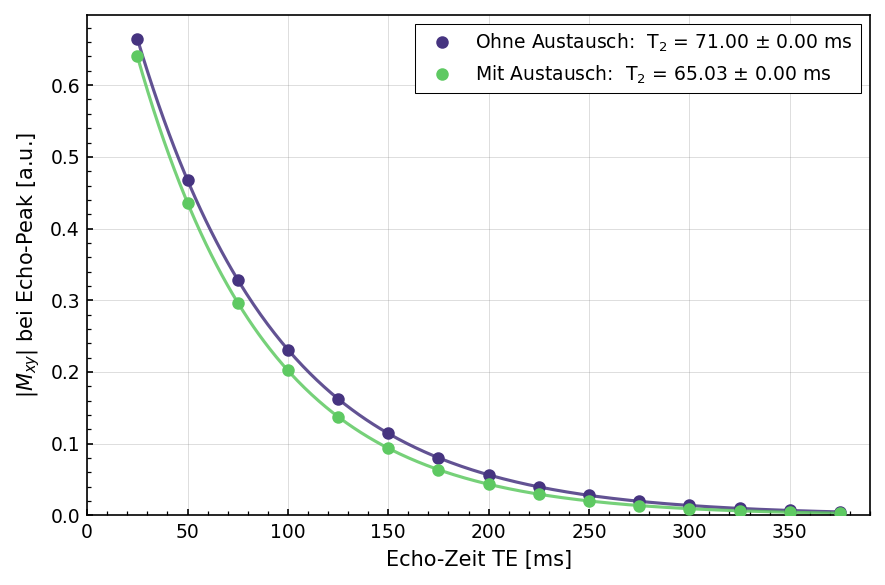


Differenz ΔT2 = 5.97 ms (Einfluss des Austauschs)


In [27]:
cmap = plt.get_cmap('viridis')

mpl.rcParams.update({
    'font.family':          'sans-serif',
    'font.size':            10,
    'axes.labelsize':       10,
    'legend.fontsize':      9,
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    'axes.linewidth':       0.8,
    'lines.linewidth':      1.5,
    'xtick.direction':      'in',
    'ytick.direction':      'in',
    'xtick.major.size':     3,
    'ytick.major.size':     3,
    'xtick.minor.visible':  True,
    'ytick.minor.visible':  True,
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
})

COLORS = {
    'Ohne Austausch': cmap(0.15),
    'Mit Austausch':  cmap(0.75),
}

fig, ax = plt.subplots(figsize=(6, 4))

for var_name, res in fit_results.items():
    color   = COLORS[var_name]
    te_fit  = np.linspace(res['te_arr'].min(), res['te_arr'].max(), 400)
    amp_fit = t2_model(te_fit, *res['popt'])

    ax.plot(res['te_arr'], res['amp_arr'], 'o', color=color,
            markersize=5, zorder=5,
            label=f"{var_name}:  T$_2$ = {res['t2_fit']:.2f} ± {res['t2_err']:.2f} ms")
    ax.plot(te_fit, amp_fit, '-', color=color, linewidth=1.5, alpha=0.85)

ax.set_xlabel('Echo-Zeit TE [ms]')
ax.set_ylabel('$|M_{xy}|$ bei Echo-Peak [a.u.]')
ax.set_xlim(0, TE_values_ms.max() + 15)
ax.set_ylim(0, None)
ax.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg = ax.legend(loc='upper right', frameon=True, fancybox=False,
                framealpha=1.0, edgecolor='black')
leg.get_frame().set_linewidth(0.5)

fig.tight_layout()

out_dir = wdir / 'results' / 'simulations'
fig.savefig(out_dir / f't2_comparison_{series_label}.pdf')
fig.savefig(out_dir / f't2_comparison_{series_label}.png')
plt.show()

print(f"\nDifferenz ΔT2 = {fit_results['Ohne Austausch']['t2_fit'] - fit_results['Mit Austausch']['t2_fit']:.2f} ms (Einfluss des Austauschs)")

## Simulationsparameter

### TE-Reihe
| Parameter | Wert |
|---|---|
| Anzahl TE-Punkte | 15 |
| TE-Bereich | 25 – 375 ms (Schrittweite 25 ms) |
| Optimaler Bereich | 0.5 × T₂ … 5 × T₂ ≈ 35 – 355 ms |

### Sequenz
| Parameter | Wert |
|---|---|
| Pulsform | Gauß (center_pos = 0.5) |
| Pulsdauer | 2 ms |
| 180°-Phase (CPMG) | π/2 |
| Echo-Zeitpunkt | t_echo = 2.5·t_pulse + TE = 5 ms + TE |
| ADC-Fenster | 50 ms |

### Configs
| Datei | k [Hz] | Rex [Hz] | T₂_eff [ms] |
|---|---|---|---|
| `config_t2fit_noex.yaml` | 0 | 0 | 71.0 ms |
| `config_t2fit_cest.yaml` | 2 000 | 1.16 | ≈ 65.6 ms |

**Rex-Formel** (Lorentz-Profil des austauschenden Pools):
$$R_\text{ex} = k \cdot f \cdot \frac{\Delta\omega^2}{\Delta\omega^2 + (2\pi k)^2}$$
Maximum bei k = Δω/2π = 5 790 Hz → Rex_max ≈ 1.88 Hz → T₂_eff,min ≈ 62.7 ms

**Gemeinsame Parameter:**
- b0_inhom = 3×10⁻⁸ → T₂* ≈ 10 ms
- water_pool: T₁ = 2.5 s, T₂ = 71 ms
- Pool: f = 6.49×10⁻⁴, Δω = 8 ppm, T₁ = 1.3 s, T₂ = 100 ms
- Physikalische Referenz: k = 2 000 Hz entspricht schnell-austauschenden Hydroxyl-/Amingruppen (Glykosaminoglykane, mobile Proteine)